In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WineQT - WineQT.csv.csv to WineQT - WineQT.csv.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import os
os.listdir()

['.config', 'WineQT - WineQT.csv.csv', 'sample_data']

In [ ]:
df = pd.read_csv("WineQT - WineQT.csv.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.shape

(7640, 12)

In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

print("\nFirst 5 rows:")
df.head()

Shape of dataset: (7640, 12)

Columns:
 Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7640 entries, 0 to 7639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         7640 non-null   float64
 1   volatile acidity      7640 non-null   float64
 2   citric acid           7640 non-null   float64
 3   residual sugar        7640 non-null   float64
 4   chlorides             7640 non-null   float64
 5   free sulfur dioxide   7640 non-null   float64
 6   total sulfur dioxide  7640 non-null   float64
 7   density               7640 non-null   float64
 8   pH                    7640 non-null   float64
 9   sulphates             7640 non-null   float64
 10  alcohol               7640 non-null   float64
 11  quality               7640 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 716.4 KB


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,7640.000000,7640.000000,7640.000000,7640.000000,7640.000000,7640.000000,7640.000000,7640.000000,7640.000000,7640.000000,7640.000000,7640.000000
mean,7.379247,0.368342,0.311113,5.007716,0.060657,28.294699,105.297513,0.995001,3.232342,0.550185,10.484367,5.794241
std,1.427803,0.180411,0.155121,4.539029,0.038719,17.660597,59.142368,0.002954,0.163531,0.158761,1.176904,0.865367
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.500000,0.240000,0.240000,1.800000,0.040000,15.000000,52.750000,0.992737,3.120000,0.440000,9.500000,5.000000
50%,7.100000,0.320000,0.300000,2.600000,0.050000,26.000000,109.000000,0.995340,3.220000,0.530000,10.300000,6.000000
75%,7.900000,0.460000,0.400000,7.350000,0.075000,39.000000,149.000000,0.997200,3.340000,0.620000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2322


In [ ]:
df = df.drop_duplicates()

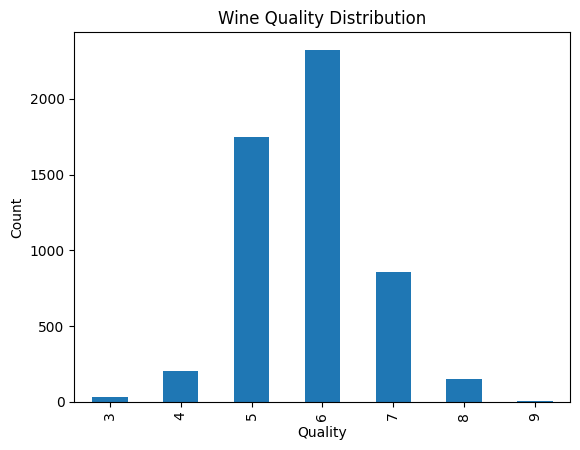

In [ ]:
plt.figure()
df["quality"].value_counts().sort_index().plot(kind='bar')
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

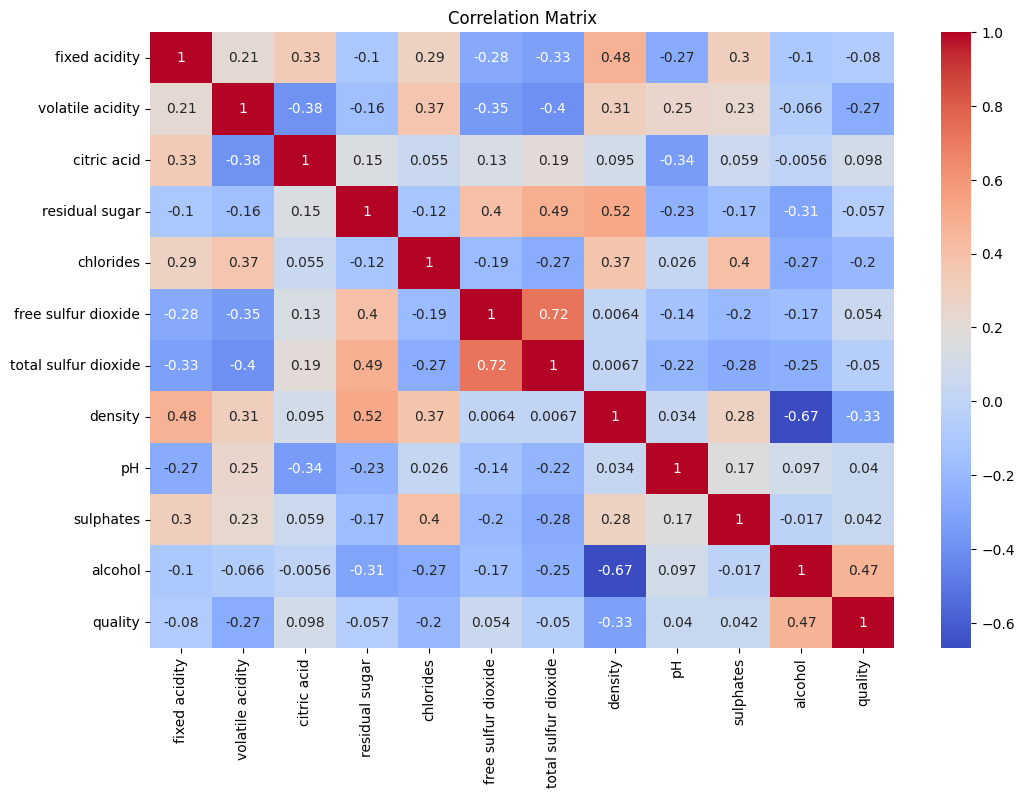

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

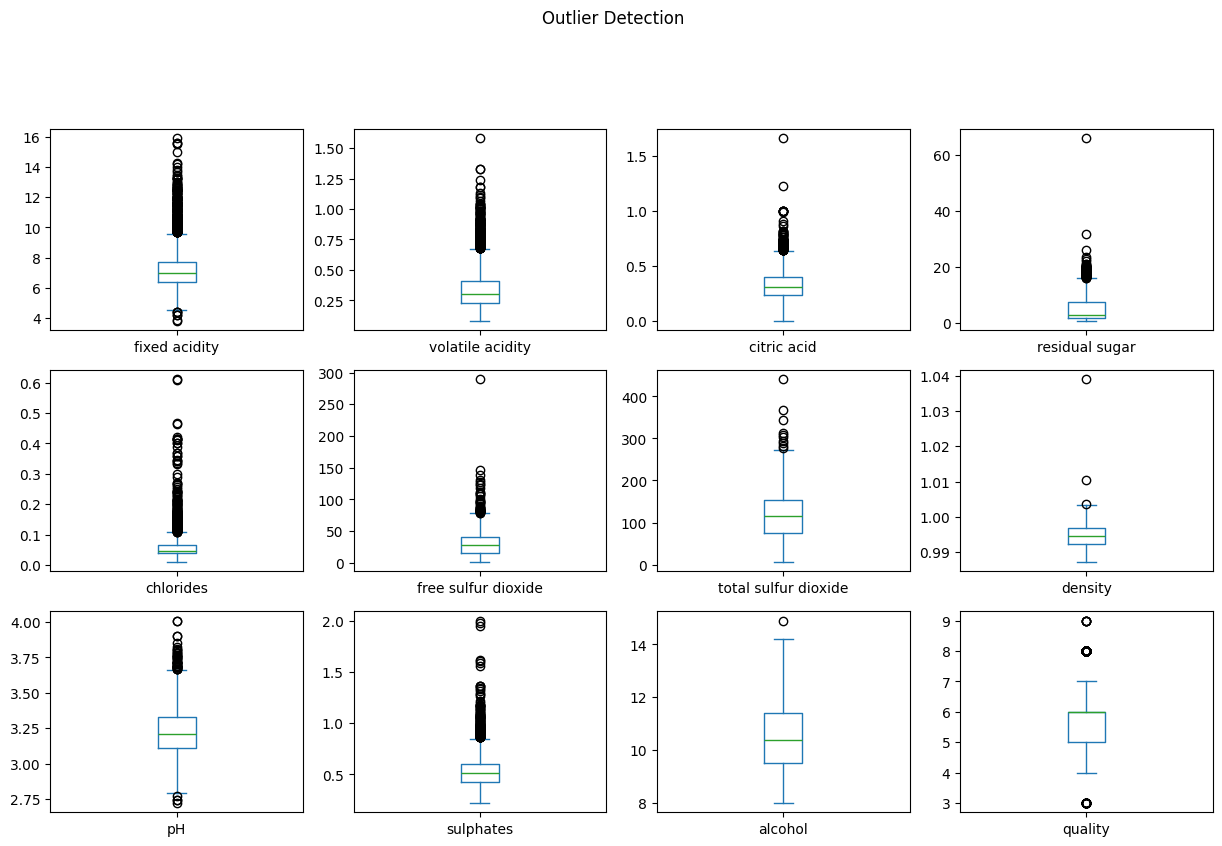

In [ ]:
df.plot(kind='box', subplots=True, layout=(4,4), figsize=(15,12))
plt.suptitle("Outlier Detection")
plt.show()

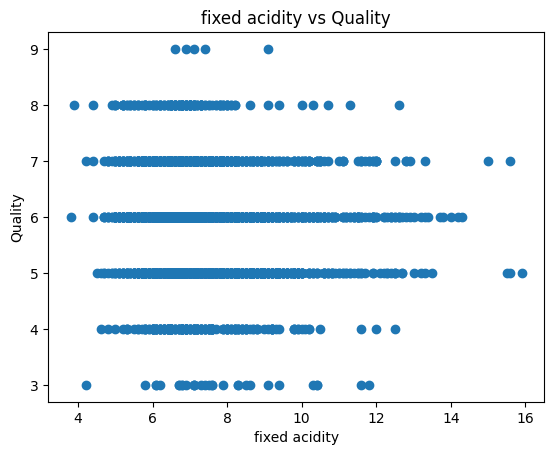

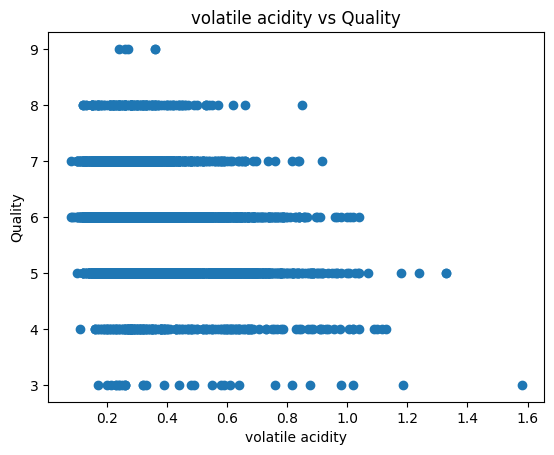

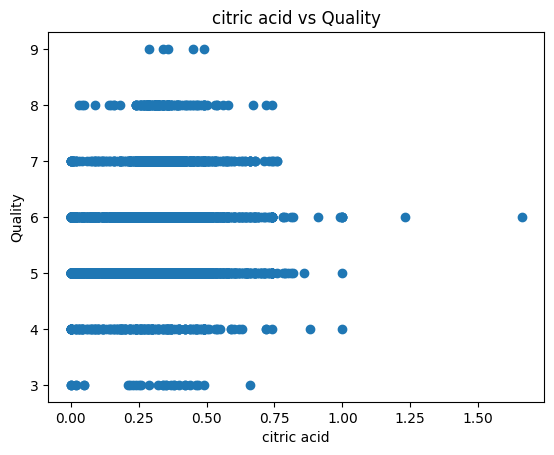

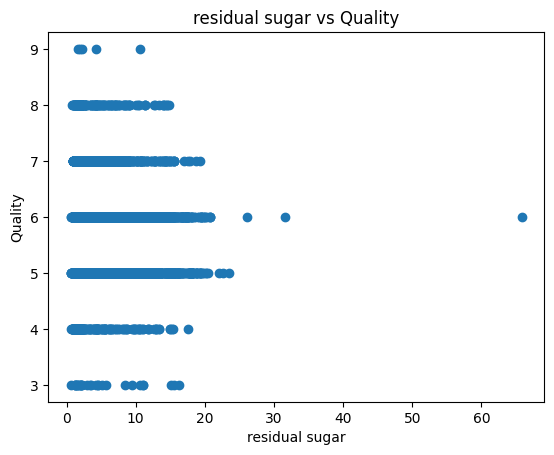

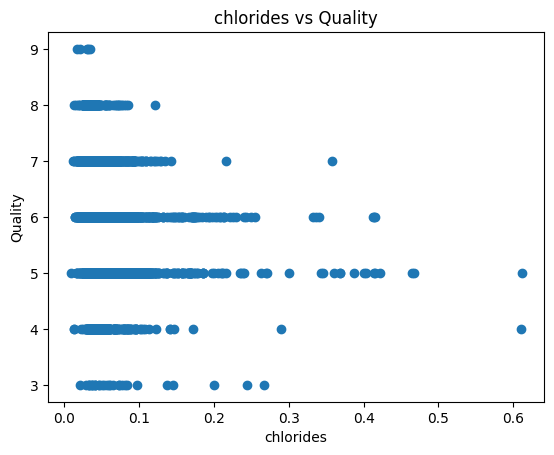

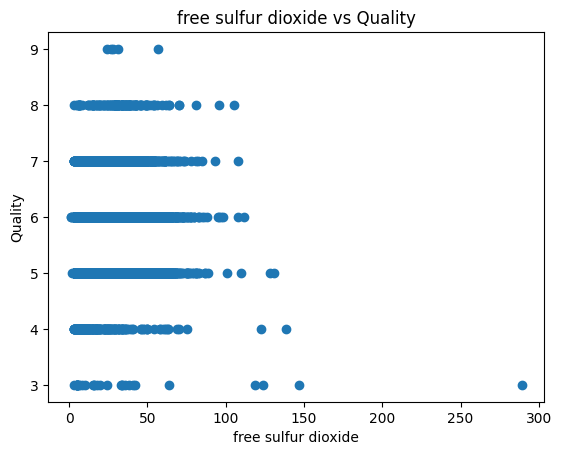

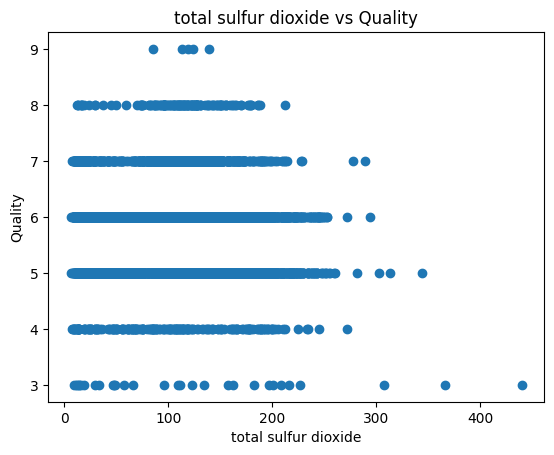

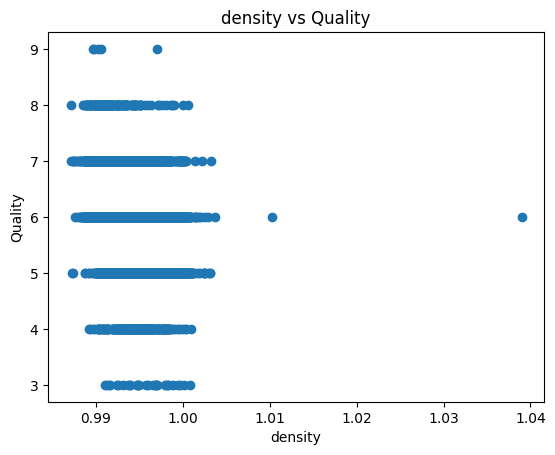

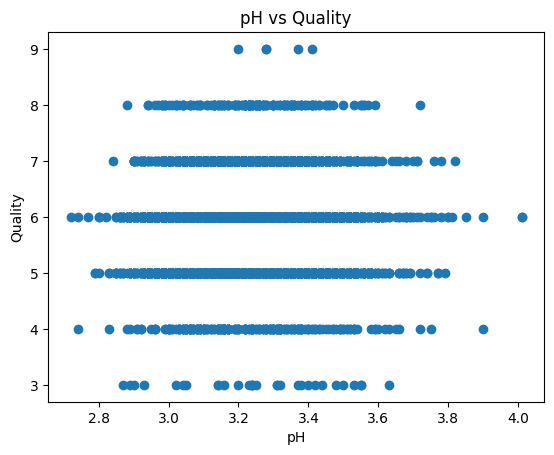

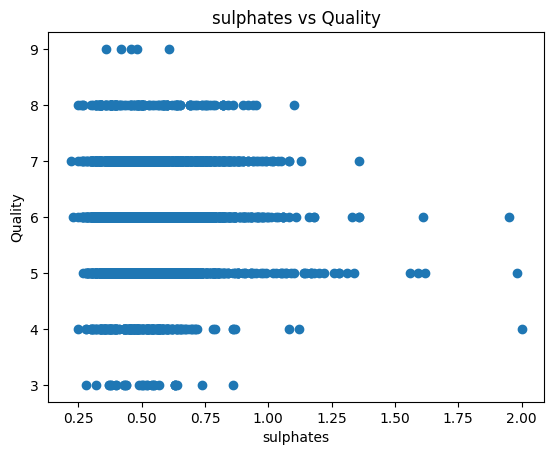

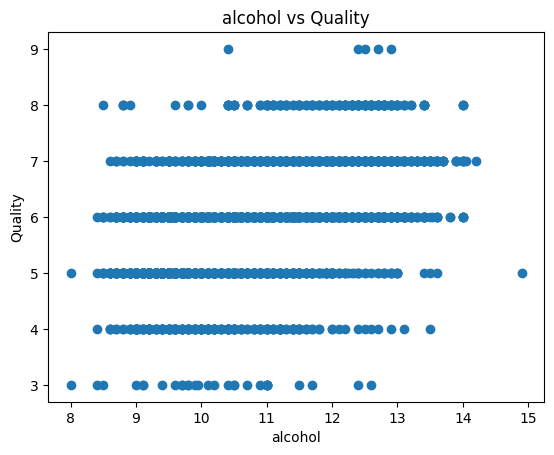

In [ ]:
features = df.drop("quality", axis=1).columns

for col in features:
    plt.figure()
    plt.scatter(df[col], df["quality"])
    plt.xlabel(col)
    plt.ylabel("Quality")
    plt.title(f"{col} vs Quality")
    plt.show()

In [ ]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5318, 11)
Target shape: (5318,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4254, 11)
Test shape: (1064, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data preview:")
print(X_train_scaled[:5])

Scaled training data preview:
[[ 0.58419044 -0.62142984  1.08340182  0.37710853 -0.26154422 -0.97049813
   0.34910331  0.54016675  0.04445053  1.13487909 -0.46350575]
 [ 2.16514403 -0.44286504  1.48838634 -0.61281105  0.2450443  -1.31271693
  -1.55539504  0.25653582 -0.3286357  -0.01352975  1.63645746]
 [-1.67431469  4.02125488 -1.88648466 -0.81079497 -0.31783183  0.62652292
  -0.51497464 -0.24732619  3.27786448 -0.35129705 -0.04351311]
 [-0.54506213  0.98565333 -0.46903884 -0.74480033 -0.23340041  0.51244999
   1.1073758  -0.80791439  0.35535571  0.2566841   0.01248591]
 [-0.39449512 -1.27616743  0.88090956 -0.19484501 -0.37411944  1.25392405
   0.29620058 -0.97475611 -1.01262711  0.05402371  0.62847512]]


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42)

rf.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=12, n_estimators=300, random_state=42)

In [ ]:
pred = rf.predict(X_test_scaled)

print("First 10 Predictions:")
print(pred[:10])

First 10 Predictions:
[6.52507715 5.47581954 5.895239   6.03798833 6.10518823 5.58040983
 5.41146018 6.33080768 5.68947694 6.07657176]


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.683883477197214
R2 Score: 0.40889644605093467


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.683883477197214
R2 Score: 0.40889644605093467


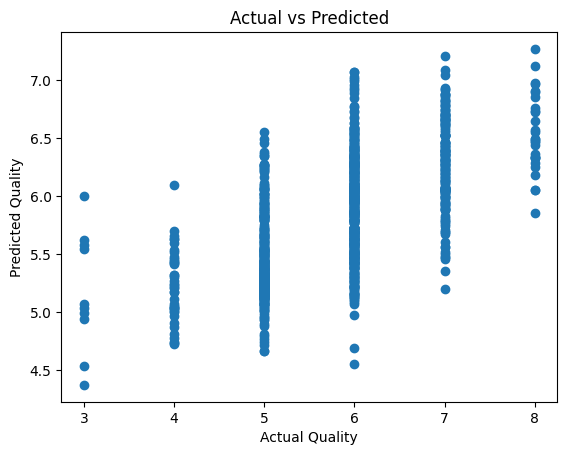

In [ ]:
plt.figure()
plt.scatter(y_test, pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted")
plt.show()

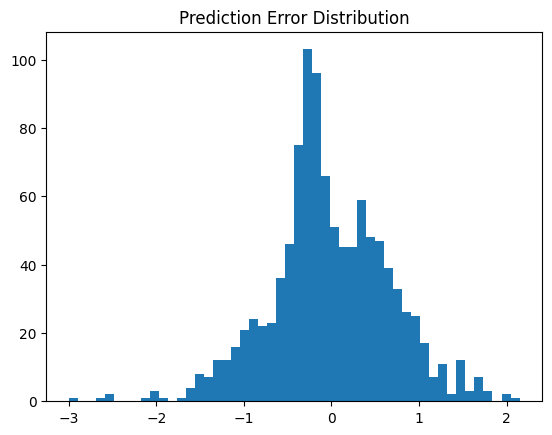

In [ ]:
error = y_test - pred

plt.figure()
plt.hist(error, bins=50)
plt.title("Prediction Error Distribution")
plt.show()

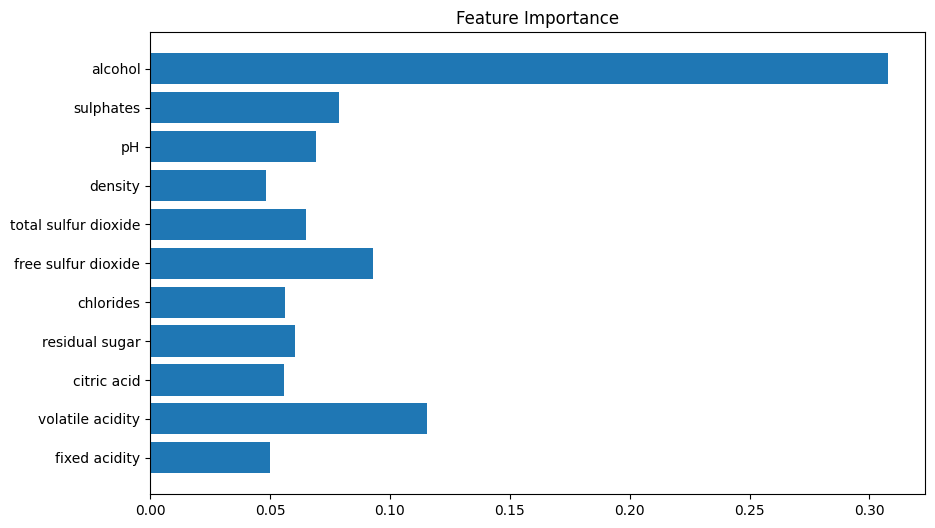

In [ ]:
importance = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

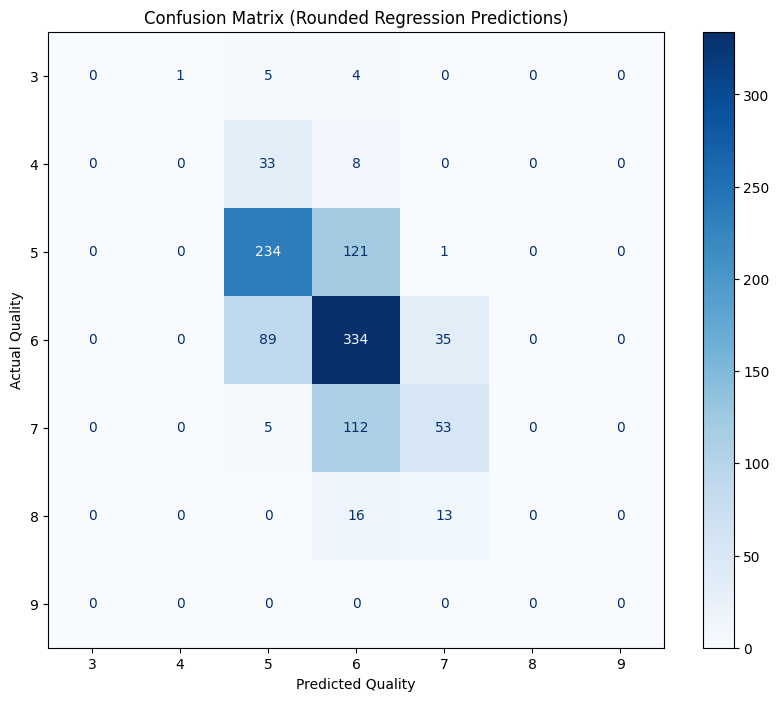

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
pred = rf.predict(X_test_scaled)
pred_rounded = np.round(pred).astype(int)
min_quality = y.min()
max_quality = y.max()
pred_rounded = np.clip(pred_rounded, min_quality, max_quality)
cm = confusion_matrix(y_test, pred_rounded, labels=np.arange(min_quality, max_quality + 1))
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(min_quality, max_quality + 1))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix (Rounded Regression Predictions)")
plt.xlabel("Predicted Quality")
plt.ylabel("Actual Quality")
plt.show()

In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, pred_rounded, average='weighted')

print(f"F1 Score (weighted): {f1:.4f}")

F1 Score (weighted): 0.5522
